In [1]:

import numpy as np
import pandas as pd
import scanpy as sc
import colorcet
import sklearn.neighbors
import scipy.sparse
import umap.umap_ as umap

In [2]:

import anndata as ad
sc_data_path = "/Users/anushka/Undergraduate-Project/obsm-anndata-file/sc_data.h5ad"
st_data_path = "/Users/anushka/Undergraduate-Project/obsm-anndata-file/st_data.h5ad"

# Load the AnnData objects
st_data = ad.read_h5ad(st_data_path)
sc_data = ad.read_h5ad(sc_data_path)

# Verify loading by checking the structure
print(st_data)
print(sc_data)

AnnData object with n_obs × n_vars = 18516 × 252
    obs: 'fovID', 'fov_x', 'fov_y', 'volume', 'center_x', 'center_y', 'slice_id', 'sample_id', 'label', 'subclass', 'class_label', 'cell_id', 'cell_type', 'batch', 'cell_label'
    var: 'n_iso'
    uns: 'COVET_genes'
    obsm: 'COVET', 'COVET_SQRT', 'cell_type_niche', 'envi_latent', 'imputation', 'spatial'
    layers: 'X', 'log1p', 'norm'
AnnData object with n_obs × n_vars = 7416 × 13061
    obs: 'aggr_num', 'umi.counts', 'gene.counts', 'library_id', 'tube_barcode', 'Seq_batch', 'Region', 'Lib_type', 'Gender', 'Donor', 'Amp_Name', 'Amp_Date', 'Amp_PCR_cyles', 'Lib_Name', 'Lib_Date', 'Replicate_Lib', 'Lib_PCR_cycles', 'Lib_PassFail', 'Cell_Capture', 'Lib_Cells', 'Mean_Reads_perCell', 'Median_Genes_perCell', 'Median_UMI_perCell', 'Saturation', 'Live_percent', 'Total_Cells', 'Live_Cells', 'method', 'exp_component_name', 'mapped_reads', 'unmapped_reads', 'nonconf_mapped_reads', 'total.reads', 'doublet.score', 'cell_type', 'cell_supertype', '

In [3]:
cell_type_palette = {'Astro': (0.843137, 0.0, 0.0, 1.0),
                     'Endo': (0.54902, 0.235294, 1.0, 1.0),
                     'L23_IT': (0.007843, 0.533333, 0.0, 1.0),
                     'L45_IT': (0.0, 0.67451, 0.780392, 1.0),
                     'L56_NP': (0.596078, 1.0, 0.0, 1.0),
                     'L5_ET': (1.0, 0.498039, 0.819608, 1.0),
                     'L5_IT': (0.423529, 0.0, 0.309804, 1.0),
                     'L5_PT': (1.0, 0.647059, 0.188235, 1.0),
                     'L6_CT': (0.345098, 0.231373, 0.0, 1.0),
                     'L6_IT': (0.0, 0.341176, 0.34902, 1.0),
                     'L6_IT_Car3': (0.0, 0.0, 0.866667, 1.0),
                     'L6b': (0.0, 0.992157, 0.811765, 1.0),
                     'Lamp5': (0.631373, 0.458824, 0.415686, 1.0),
                     'Microglia': (0.737255, 0.717647, 1.0, 1.0),
                     'OPC': (0.584314, 0.709804, 0.470588, 1.0),
                     'Oligo': (0.752941, 0.015686, 0.72549, 1.0),
                     'Pericytes': (0.392157, 0.329412, 0.454902, 1.0),
                     'Pvalb': (0.47451, 0.0, 0.0, 1.0),
                     'SMC': (0.027451, 0.454902, 0.847059, 1.0),
                     'Sncg': (0.996078, 0.960784, 0.564706, 1.0),
                     'Sst': (0.0, 0.294118, 0.0, 1.0),
                     'VLMC': (0.560784, 0.478431, 0.0, 1.0),
                     'Vip': (1.0, 0.447059, 0.4, 1.0)}

cell_label_palette = {'GABAergic': (0.843137, 0.0, 0.0, 1.0),
                      'Glutamatergic': (0.54902, 0.235294, 1.0, 1.0),
                      'Non-Neuronal': (0.007843, 0.533333, 0.0, 1.0)}

In [4]:
# Flatten the (64, 64) matrices into 1D vectors
st_covet_sqrt_flat = st_data.obsm["COVET_SQRT"].reshape(st_data.shape[0], -1)
sc_covet_sqrt_flat = sc_data.obsm["COVET_SQRT"].reshape(sc_data.shape[0], -1)

# Combine both datasets for joint UMAP
covet_sqrt_combined = np.concatenate([st_covet_sqrt_flat, sc_covet_sqrt_flat], axis=0)

In [5]:
cell_types_sc = sc_data.obs["cell_type"].values
cell_types_st = st_data.obs["cell_type"].values
combined_cell_types = np.concatenate((cell_types_sc, cell_types_st), axis=0)


In [13]:
combined_cell_types.shape

(25932,)

In [6]:
covet_sqrt_combined

array([[ 7.12395355e-04, -2.61447043e-03,  2.05038174e-04, ...,
         5.53785041e-02, -5.56620918e-02,  1.93564534e-01],
       [ 6.36535464e-04, -4.07962920e-03,  5.45900664e-04, ...,
         2.36149430e-02, -5.49935363e-02,  1.03644766e-01],
       [ 6.32807321e-04,  3.31655890e-03, -4.97922709e-04, ...,
        -8.86420999e-03,  2.05024518e-02,  1.03581749e-01],
       ...,
       [ 3.36207449e-05,  3.28421593e-03, -4.01679426e-05, ...,
         2.64329202e-02,  3.86447981e-02,  4.00460601e-01],
       [ 1.28799677e-03,  1.83649063e-02,  7.27236271e-04, ...,
         1.30811706e-03,  4.86928001e-02,  4.95014012e-01],
       [ 1.64285302e-04, -7.35998154e-03, -1.48639083e-05, ...,
         2.53679454e-02,  4.83936705e-02,  4.05316740e-01]], dtype=float32)

In [7]:
adata_combined = ad.AnnData(X=covet_sqrt_combined)
adata_combined.obs["cell_type"] = combined_cell_types

In [8]:
adata_combined

AnnData object with n_obs × n_vars = 25932 × 4096
    obs: 'cell_type'

In [11]:
adata_combined.obsm["covet_sqrt"] = covet_sqrt_combined

In [14]:
adata_combined

AnnData object with n_obs × n_vars = 25932 × 4096
    obs: 'cell_type', 'leiden'
    uns: 'pca', 'neighbors', 'leiden', 'umap', 'leiden_colors', 'cell_type_colors'
    obsm: 'envi_latent', 'X_pca', 'covet_sqrt', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

/var/folders/d4/bgr0tr5d43z2xmtq5hk3s4n00000gn/T/ipykernel_71658/435105218.py:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_combined)


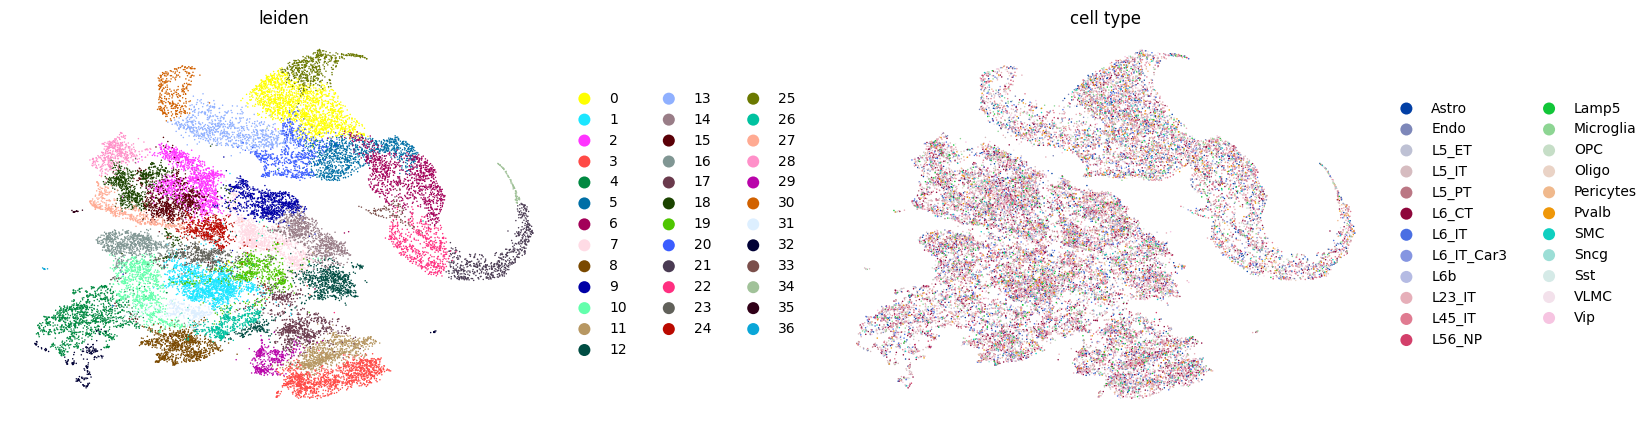

In [ ]:
sc.pp.neighbors(adata_combined, n_neighbors=10, n_pcs=40)
sc.tl.leiden(adata_combined)
sc.tl.umap(adata_combined)
sc.pl.scatter(adata_combined, basis='umap', color=['leiden', 'cell_type'], frameon=False)